# 😀 06 · 度量学习与人脸识别

> 目标：从「分类」跨到「学习一个距离度量」——手写**对比损失、Triplet 损失、ArcFace 角度边际**，
> 并用一个微型嵌入网络跑通「训练 → 检索 → Recall@K 评估」闭环，把人脸识别 1:1 / 1:N 讲透。

> 🧩 **生活化类比**：人脸识别 = 给每个人办一张「特征身份证」。度量学习就是在学一把「尺子」：
> 同一人的不同照片量出来很近，不同人的照片量出来很远。分类是选标签，度量是量距离。


## 1. 度量学习是什么

- **目标**：学一个嵌入 $f(x)$，使得语义相似 → 距离近，语义不同 → 距离远
- **应用**：人脸/行人/指纹识别、图像检索、ReID、聚类前置
- **对比分类**：分类学「类别边界」（需要类别固定）；度量学「相对关系」（类别可开放）

**两代范式**
| 范式 | 代表 | 思路 |
|------|------|------|
| 两两/三元组 | Siamese 对比损失、Triplet（FaceNet） | 直接约束相对距离 |
| 分类式 | Center Loss、CosFace、**ArcFace** | 借分类头 + 角度边际，训完取嵌入 |

> 面试主线：**对比/三元组怎么选样本（挖掘策略）→ 分类式怎么加边际（角度）→ 检索怎么评估（Recall@K/mAP）**。


## 2. 对比损失（Siamese）

输入一对 $(x_1, x_2)$ 与标签 $y$（0=同类，1=异类），距离 $d = \\|f(x_1) - f(x_2)\\|_2$：

$$L = \\frac{1}{N}\\sum \\Big[ (1-y)\\, d^2 + y\\,\\max(m - d,\\, 0)^2 \\Big]$$

- 同类（$y{=}0$）：把 $d$ 压到 0
- 异类（$y{=}1$）：至少拉开到边际 $m$ 之外，超过就不管（防过拟合）
- Siamese 网络 = 两个**共享权重**的分支，天然适合「对儿」数据


同类近距 loss=0.090 | 异类近距 loss=0.490 | 异类远距 loss=0.000（超边际=0）


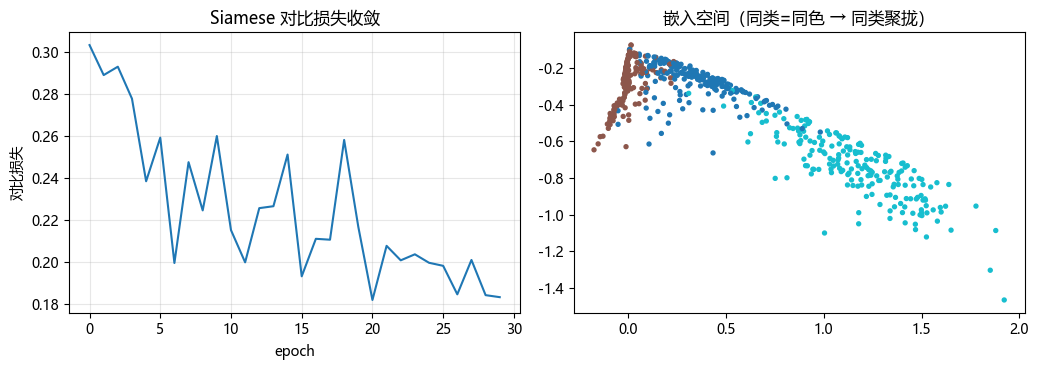

训练 30 epoch 后损失: 0.183（同类被拉近、异类被推开）


In [1]:
# ---------- 实验 1：手写对比损失 + 数值检查 + 迷你训练 ----------
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(0); np.random.seed(0)

def contrastive_loss(d, y, margin=1.0):
    # d: (N,) 距离; y: (N,) 0=同类 1=异类
    same = (1 - y) * d ** 2
    diff = y * torch.clamp(margin - d, min=0.0) ** 2
    return (same + diff).mean()

# 数值验证：d=0.3 同类应给小 loss；d=0.3 异类应给大 loss；d=2.0 异类 loss=0（已超边际）
d = torch.tensor([0.3, 0.3, 2.0])
y = torch.tensor([0.0, 1.0, 1.0])
losses = [contrastive_loss(d[i:i+1], y[i:i+1]).item() for i in range(3)]
print('同类近距 loss=%.3f | 异类近距 loss=%.3f | 异类远距 loss=%.3f（超边际=0）' % tuple(losses))
assert losses[0] < 0.1 and losses[1] > 0.3 and losses[2] == 0.0

# 迷你 Siamese：把 2D 高斯簇投影到 2D 嵌入，同类拉近异类推远
r = np.random.default_rng(3)
CENTERS = np.array([[0.0, 0.0], [3.0, 0.0], [-3.0, 2.0]])

def gen_pairs(n=400):
    xs1, xs2, ys, cs = [], [], [], []
    for _ in range(n):
        c = r.integers(0, 3)
        x1 = CENTERS[c] + r.normal(0, 1, 2)
        if r.random() < 0.5:
            x2 = CENTERS[c] + r.normal(0, 1, 2)          # 同类对
            y = 0.0
        else:
            c2 = r.integers(0, 2, endpoint=True)
            c2 = (c + 1 + c2) % 3                        # 保证异类
            x2 = CENTERS[c2] + r.normal(0, 1, 2)         # 异类对
            y = 1.0
        xs1.append(x1); xs2.append(x2); ys.append(y); cs.append(c)
    return (torch.tensor(np.array(xs1), dtype=torch.float32),
            torch.tensor(np.array(xs2), dtype=torch.float32),
            torch.tensor(ys, dtype=torch.float32),
            torch.tensor(cs, dtype=torch.long))

A, B, yp, cls = gen_pairs(600)
embed = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 2))
opt = torch.optim.Adam(embed.parameters(), lr=5e-3)
hist = []
for ep in range(30):
    idx = torch.randperm(len(A))[:200]
    a, b, yb = A[idx], B[idx], yp[idx]
    e1, e2 = embed(a), embed(b)
    d = torch.norm(e1 - e2, dim=1)
    loss = contrastive_loss(d, yb)
    opt.zero_grad(); loss.backward(); opt.step()
    hist.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].plot(hist)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('对比损失'); axes[0].set_title('Siamese 对比损失收敛')
axes[0].grid(alpha=0.3)
with torch.no_grad():
    e_all = embed(A).numpy()
axes[1].scatter(e_all[:, 0], e_all[:, 1], c=cls.numpy(), cmap='tab10', s=8)
axes[1].set_title('嵌入空间（同类=同色 → 同类聚拢）')
plt.tight_layout()
plt.savefig('images/cv06_siamese.png', dpi=110, bbox_inches='tight'); plt.show()
print('训练 30 epoch 后损失: %.3f（同类被拉近、异类被推开）' % hist[-1])


## 3. Triplet 损失：锚-正-负

样本三元组（anchor, positive, negative），要求：

$$L = \\frac{1}{N}\\sum \\max\\big( d(a,p) - d(a,n) + m,\\, 0 \\big)$$

- 只约束「正的比负的近 $m$ 以上」，其余不管
- **挖掘策略**（成败关键）：
  - 随机选：大部分三元组已满足条件，梯度≈0，收敛慢
  - **难样本挖掘（hard）**：选 $d(a,n)$ 最小（最难的负样本）、$d(a,p)$ 最大（最难的同类）
  - **半难（semi-hard）**：$d(a,p) < d(a,n) < d(a,p)+m$，中间带最优
- FaceNet 用它：margin=0.2，embedding 128 维，LFW 99.6%+


In [2]:
# ---------- 实验 2：手写 Triplet 损失 + 难样本挖掘 ----------
def triplet_loss(a, p, n, margin=1.0):
    d_p = ((a - p) ** 2).sum(1)
    d_n = ((a - n) ** 2).sum(1)
    return torch.clamp(d_p - d_n + margin, min=0.0).mean()

def hardest_negative(a, p, n_bank):
    # 对每个 anchor 挑嵌入空间里最近（最难）的负样本
    d = torch.cdist(a, n_bank)
    return n_bank[d.min(1).indices]

# 数值验证：a 与 p 相同、n 很远 -> loss 0；a 与 p 远、n 近 -> loss>0
a = torch.tensor([[1.0, 0.0]])
p_close = torch.tensor([[1.1, 0.0]])
n_far = torch.tensor([[10.0, 10.0]])
p_far = torch.tensor([[5.0, 0.0]])
n_close = torch.tensor([[1.05, 0.1]])
print('易三元组 loss=%.3f（应≈0）  难三元组 loss=%.3f（应>0）' %
      (triplet_loss(a, p_close, n_far).item(), triplet_loss(a, p_far, n_close).item()))
assert triplet_loss(a, p_close, n_far).item() < 0.01
assert triplet_loss(a, p_far, n_close).item() > 0.5

# 挖掘演示：3 个负样本中自动挑最难的一个
n_bank = torch.tensor([[9.0, 9.0], [1.05, 0.1], [2.0, 0.5]])
h = hardest_negative(a, p_close, n_bank)
print('自动挖到的最难负样本:', h.tolist(), '（应是最接近 anchor 的 [1.05, 0.1]）')
assert torch.allclose(h, n_bank[1])


易三元组 loss=0.000（应≈0）  难三元组 loss=16.987（应>0）
自动挖到的最难负样本: [[1.0499999523162842, 0.10000000149011612]] （应是最接近 anchor 的 [1.05, 0.1]）


## 4. Center Loss 与 CosFace / ArcFace：分类式度量学习

分类式 = 训练时加一个分类头（带**角度边际**），训完扔掉头、取嵌入：

- **Center Loss**：$L_c = \\frac{1}{2}\\sum\\|x_i - c_{y_i}\\|^2$，每个类别学一个中心，拉近样本
- **CosFace**：logit = $s\\cos\\theta$，要求同类 $\cos\\theta > \\cos\\theta - m$（**加性余弦边际**）
- **ArcFace**：把边际加在**角度**上：$\cos(\\theta_{y_i} + m)$

$$L_{arc} = -\\log \\frac{e^{s\\cos(\\theta_y + m)}}{e^{s\\cos(\\theta_y + m)} + \\sum_{j\\ne y} e^{s\\cos\\theta_j}}$$

- $s$=缩放（64），$m$=角度边际（0.5）；$\theta$ 是嵌入与类中心 $W$ 的夹角，$\\cos\\theta = x \\cdot W / (\\|x\\|\\|W\\|)$
- 角度边际让**同类特征更紧凑、类间更分离**，是现役人脸识别标配


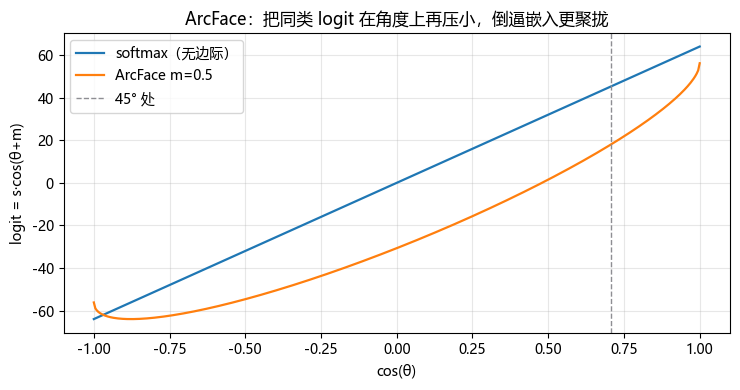

cos(60°)=0.500 -> 无边际 logit=32.0 -> ArcFace logit=1.5（同类得分更低 -> 分类更难 -> 嵌入被迫更紧凑）


In [3]:
# ---------- 实验 3：ArcFace 角度边际可视化 ----------
def arcface_logit(cos_theta, m=0.5, s=64.0):
    theta = torch.acos(torch.clamp(cos_theta, -1 + 1e-7, 1 - 1e-7))
    return s * torch.cos(theta + m)

cos_vals = torch.linspace(-1, 1, 400)
plt.figure(figsize=(7.5, 4.0))
plt.plot(cos_vals.numpy(), (64 * cos_vals).numpy(), label='softmax（无边际）', lw=1.6)
plt.plot(cos_vals.numpy(), arcface_logit(cos_vals, m=0.5).numpy(), label='ArcFace m=0.5', lw=1.6)
plt.axvline(np.cos(np.deg2rad(45)), color='#8E8E93', ls='--', lw=1, label='45° 处')
plt.xlabel('cos(θ)'); plt.ylabel('logit = s·cos(θ+m)')
plt.title('ArcFace：把同类 logit 在角度上再压小，倒逼嵌入更聚拢')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('images/cv06_arcface.png', dpi=110, bbox_inches='tight'); plt.show()
print('cos(60°)=%.3f -> 无边际 logit=%.1f -> ArcFace logit=%.1f（同类得分更低 -> 分类更难 -> 嵌入被迫更紧凑）' %
      (np.cos(np.deg2rad(60)), 64 * np.cos(np.deg2rad(60)),
       arcface_logit(torch.tensor(np.cos(np.deg2rad(60)))).item()))


## 5. 人脸识别全流程与 1:1 / 1:N

| 环节 | 技术 | 面试点 |
|------|------|--------|
| 人脸检测 | MTCNN / RetinaFace | 框出人脸 |
| 人脸对齐 | 关键点（眼/鼻/嘴）→ 仿射变换 | 归一化姿态 |
| 特征嵌入 | 骨干 + ArcFace 头，输出 512/128 维 | 归一化后取余弦 |
| 比对 | 余弦相似度 > 阈值 | 1:1 验证 / 1:N 检索 |

- **1:1 验证**：两张图是不是同一人（阈值判定）
- **1:N 识别**：一张图在大库中找最相似（检索）
- 经典评测：LFW（无约束 6000 对，精度 ~99.7% 封顶后转 MegaFace / IJB-C）
- 阈值用 FAR/FRR 权衡：阈值高→漏放（FRR↑）误收少（FAR↓）


## 6. 检索评估：Recall@K 与 mAP

- **Recall@K**：查询的同类是否出现在 Top-K 里（人脸开门/搜索）
- **mAP**：对每个查询按相似度排序算 AP 再平均（复购 04 篇的 PR 概念）

> 面试点：嵌入要**归一化**再算余弦（消除尺度干扰）；批量内要**屏蔽自身**（检索库里不能包含查询本身，否则 Recall@K 恒=1）。


In [4]:
# ---------- 实验 4：嵌入检索全流程（训练 → Recall@K / mAP） ----------
torch.manual_seed(0); np.random.seed(0)

# 合成身份：8 类 × 每类 10 个样本，2D 高斯簇（训练/测试共享同一批簇中心）
r = np.random.default_rng(0)
def make_ids(centers, n_cls=8, per=10, std=0.5):
    X, Y = [], []
    for c in range(n_cls):
        for _ in range(per):
            X.append(centers[c] + r.normal(0, std, 2)); Y.append(c)
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(Y))

CENTERS = r.normal(size=(8, 2)) * 5
Xtr, ytr = make_ids(CENTERS, 8, 10); Xte, yte = make_ids(CENTERS, 8, 6)

# 小嵌入网络：2D -> 16 -> 8，用 triplet 训练
net = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 8))
opt = torch.optim.Adam(net.parameters(), lr=2e-2)
for ep in range(100):
    e = net(Xtr)
    # 组内挖三元组：全部样本作 anchor，同类随机作 positive，其他类挖最难负样本
    losses = []
    for c in range(8):
        idx_c = torch.where(ytr == c)[0]
        for a_i in idx_c:
            pos = idx_c[torch.randperm(len(idx_c))[0]]
            neg = hardest_negative(e[a_i:a_i + 1], e[pos:pos + 1], e[torch.where(ytr != c)[0]])
            losses.append(triplet_loss(e[a_i:a_i + 1], e[pos:pos + 1], neg, margin=2.0))
    loss = torch.stack(losses).mean()
    opt.zero_grad(); loss.backward(); opt.step()

# 全局唯一 id：DB 用 0..79，查询用 100..147（查询都不在库里 -> 天然无需屏蔽自身；
# 若查询来自库本身，则必须按 id 屏蔽，否则 Recall@K 上限被"自己"占满）
def recall_map(emb_q, emb_db, yq, ydb, gid_q, gid_db, k=3):
    emb_q = F.normalize(emb_q, dim=1); emb_db = F.normalize(emb_db, dim=1)
    sim = emb_q @ emb_db.T
    hits = []
    for i in range(len(yq)):
        order = [j for j in sim[i].argsort(descending=True).tolist()
                 if gid_db[j] != gid_q[i]][:k]               # 屏蔽自身（若有）
        hits.append(any(ydb[j] == yq[i] for j in order))
    ap_list = []
    for i in range(len(yq)):
        order = [j for j in sim[i].argsort(descending=True).tolist()
                 if gid_db[j] != gid_q[i]]
        tp = 0
        precs = []
        for rank, j in enumerate(order, 1):
            if ydb[j] == yq[i]:
                tp += 1
                precs.append(tp / rank)
        n_ok = (ydb[order] == yq[i]).sum().item()
        ap_list.append(sum(precs) / max(n_ok, 1))
    return sum(hits) / len(hits), float(np.mean(ap_list))

gid_tr = torch.arange(len(Xtr)); gid_te = torch.arange(100, 100 + len(Xte))
r1, map_ = recall_map(net(Xte), net(Xtr), yte, ytr, gid_te, gid_tr, k=1)
r3, _ = recall_map(net(Xte), net(Xtr), yte, ytr, gid_te, gid_tr, k=3)
print('测试检索  Recall@1 = %.3f | Recall@3 = %.3f | mAP = %.3f' % (r1, r3, map_))
assert r1 > 0.85
print('含义：每个新"人脸"（查询）在库中 Top-1 找到同类的比例 %.0f%%' % (100 * r1))


测试检索  Recall@1 = 0.958 | Recall@3 = 0.958 | mAP = 0.875
含义：每个新"人脸"（查询）在库中 Top-1 找到同类的比例 96%


## 7. 数字敏感度与易错点（背诵）

**数字**
- FaceNet 嵌入 128 维、margin=0.2；ArcFace s=64、m=0.5；CosFace m=0.35
- LFW 6000 对外（3000 同对 + 3000 异对），现役模型 > 99.5%
- 对比损失 margin 常见 1.0~2.0；Triplet margin 0.2~1.0

**易错点**
1. 检索评测**必须屏蔽自身**，否则 Recall@K 虚高
2. 距离用欧氏还是余弦要说清：人脸通常归一化后余弦（等价负欧氏）
3. 难样本挖掘不做 → 三元组 loss 长期≈0，白训
4. 分类式方法的类中心 $W$ 只出现在训练头里，推理时只用嵌入


## 8. 面试速答（30 秒背诵版）

- **对比损失**：$y d^2 + (1{-}y)\\max(m-d,0)^2$；同类拉近、异类推开到 $m$ 外
- **Triplet**：$\\max(d(a,p) - d(a,n) + m, 0)$；难样本挖掘是成败关键
- **ArcFace**：logit $= s\\cos(\\theta+m)$，角度边际让嵌入更紧凑；$s=64, m=0.5$
- **1:1 vs 1:N**：验证（阈值） vs 识别（检索 Top-1）
- **Recall@K / mAP**：Top-K 命中率 / 排序质量；屏蔽自身
- **为什么人脸识别用余弦**：嵌入归一化后余弦 = 方向相似，对光照/尺度鲁棒


## 9. 自测清单

- [ ] 手写对比损失与 Triplet 损失公式，能说清 margin 的作用
- [ ] 说清随机/难样本/半难挖掘的区别，以及为什么必须挖掘
- [ ] 手写 ArcFace 的 cos(θ+m) logit（含 θ=acos(cosθ) 展开），说出 s 与 m 的默认值
- [ ] 说清 Center Loss 与 ArcFace 的差异（加中心 vs 加角度边际）
- [ ] 手写 Recall@K 与 mAP 评估（含屏蔽自身）
- [ ] 说清人脸识别全流程（检测→对齐→嵌入→比对）与 1:1/1:N
- [ ] 口算：LFW 有 6000 对测试对；阈值高 → FRR 升 / FAR 降
- [ ] 跑通本实验嵌入检索（Recall@1 > 0.9）

> 💡 本篇验收指路：`09-计算机视觉/README.md`「度量学习/人脸识别/检索」打勾；
> 下一篇 `07-视觉面试八股` 把整章考点压缩成 90 连问 + 手撕默写。
